In [27]:
 import torch
print(torch.__version__)
print("CUDA available:", torch.cuda.is_available())
import torchaudio
import numpy as np
print(torchaudio.__version__)
import matplotlib.pyplot as plt

2.10.0+cpu
CUDA available: False
2.10.0+cpu


In [22]:
def sin_wav(freq, Fs, duration):
    t = torch.linspace(0,duration,int(Fs*duration))
    return torch.sin(t*2*np.pi*freq)

def make_phase(freq, Fs, duration):
    # returns the phase ramp tensor before sin is applied
    t = torch.linspace(0, duration, int(Fs*duration))
    return t * (2*np.pi) * freq
def apply_phase_mod(phase, modulation):
    # adds modulation to phase and applies sin, returns audio signal
    modulated_phase = phase+modulation
    return torch.sin(modulated_phase)

In [23]:
def operator(freq, Fs, duration, level, modulation=None):
    # returns operator output tensor [n_samples]
    self_phase = make_phase(freq, Fs, duration)
    if modulation is None:
        modulation = torch.zeros_like(self_phase)
    return apply_phase_mod(self_phase,modulation) * level
    
    

In [26]:
def fm_renderer(f0, ratios, levels, mod_matrix, carrier_weights, Fs, duration):
    # compute details of each operator
    num_samples = int( Fs*duration )
    num_ops = 4

    t = torch.linspace(0, duration, num_samples)
    freqs = f0 * ratios
    # more effecient than make_phase in a loop
    phase = 2 * torch.pi * freqs.unsqueeze(1) * t.unsqueeze(0)

    # compute operator signals
    raw = torch.sin(phase) * levels.unsqueeze(1) # [4, num_samples]
    feedback = torch.roll(raw, 1, dims=1) * torch.diag(mod_matrix).unsqueeze(1)
    feedback[:,0] = 0.0

    # compute modulated phase
    # for i in range num_ops:
    #     for j in range num_ops:
    #         if i == j:
    #             phase_mod[i] += feedback[i, :]
    #         else:
    #             phase_mod[i] += mod_matrix[i][j] * raw[j]

    phase_mod = torch.matmul(mod_matrix, raw)
    # apply the feedback values
    diag = torch.diag(mod_matrix)
    phase_mod -= diag.unsqueeze(1) * raw
    phase_mod += diag.unsqueeze(1) * feedback
    
        
    

Shape:  torch.Size([44100])
Shape:  torch.Size([44100])
PhaseMod with silence == original:  True
Operator matches sin wav:  True
Half amp max:  0.5


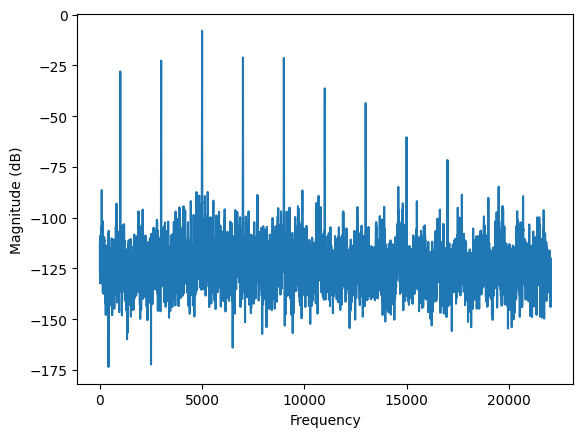